In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [20]:
path="dataset/match_prediction_features.csv"

df = pd.read_csv(path)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 66 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   match_id                       104 non-null    int64  
 1   date                           104 non-null    str    
 2   kickoff_time_utc               104 non-null    str    
 3   stage_id                       104 non-null    int64  
 4   is_knockout                    104 non-null    int64  
 5   home_team_id                   104 non-null    int64  
 6   home_team_name                 104 non-null    str    
 7   home_fifa_code                 104 non-null    str    
 8   home_confederation             104 non-null    str    
 9   away_team_id                   104 non-null    int64  
 10  away_team_name                 104 non-null    str    
 11  away_fifa_code                 104 non-null    str    
 12  away_confederation             104 non-null    str    
 13  v

In [21]:
ids = ["match_id", "stage_id", "home_team_id", "away_team_id", "venue_id", "referee_id"]
binarias = ["is_knockout", "home_is_host", "away_is_host"]
categoricas = df.select_dtypes(exclude="number").columns.tolist()
numericas = df.select_dtypes("number").columns.difference(ids + binarias, sort=False).tolist()

## ESTADISTICA DESCRIPTIVA

### Variables Numericas

In [22]:
df[numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
venue_capacity,104.0,6.752167e+04,1.197914e+04,3.000000e+04,6.476700e+04,6.979600e+04,7.326900e+04,8.250000e+04
venue_elevation_meters,104.0,2.596635e+02,5.383228e+02,2.000000e+00,7.750000e+00,3.000000e+01,2.640000e+02,2.200000e+03
referee_avg_cards,104.0,4.283654e+00,6.453885e-01,2.900000e+00,3.900000e+00,4.200000e+00,4.800000e+00,5.500000e+00
home_fifa_rank,104.0,2.475962e+01,2.221977e+01,1.000000e+00,6.000000e+00,1.700000e+01,3.900000e+01,8.500000e+01
away_fifa_rank,104.0,3.175962e+01,2.321972e+01,1.000000e+00,1.100000e+01,2.550000e+01,5.100000e+01,8.500000e+01
home_elo,104.0,1.867981e+03,1.720162e+02,1.510000e+03,1.740000e+03,1.850000e+03,2.010000e+03,2.150000e+03
away_elo,104.0,1.810962e+03,1.595246e+02,1.510000e+03,1.687500e+03,1.797500e+03,1.920000e+03,2.150000e+03
home_squad_avg_age,104.0,2.787985e+01,1.080865e+00,2.584900e+01,2.697267e+01,2.777444e+01,2.853994e+01,3.042658e+01
away_squad_avg_age,104.0,2.785269e+01,1.111936e+00,2.584900e+01,2.691476e+01,2.761449e+01,2.864418e+01,3.042658e+01
home_squad_total_caps,104.0,9.368365e+02,2.165284e+02,5.310000e+02,8.027500e+02,9.045000e+02,1.079000e+03,1.586000e+03


### Variables Categóricas

In [23]:
df[categoricas].describe().T

,count,unique,top,freq
date,104,35,2026-06-26,6
kickoff_time_utc,104,21,18:00,23
home_team_name,104,48,France,6
home_fifa_code,104,48,FRA,6
home_confederation,104,6,UEFA,45
away_team_name,104,48,Morocco,5
away_fifa_code,104,48,MAR,5
away_confederation,104,6,UEFA,35
stadium_name,104,16,Dallas Stadium (AT&T Stadium),9
venue_city,104,16,Arlington,9


## 2. Tipos de variables

In [24]:
df[numericas].info()

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 43 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   venue_capacity                 104 non-null    int64  
 1   venue_elevation_meters         104 non-null    float64
 2   referee_avg_cards              104 non-null    float64
 3   home_fifa_rank                 104 non-null    int64  
 4   away_fifa_rank                 104 non-null    int64  
 5   home_elo                       104 non-null    float64
 6   away_elo                       104 non-null    float64
 7   home_squad_avg_age             104 non-null    float64
 8   away_squad_avg_age             104 non-null    float64
 9   home_squad_total_caps          104 non-null    int64  
 10  away_squad_total_caps          104 non-null    int64  
 11  home_squad_total_value_eur     104 non-null    float64
 12  away_squad_total_value_eur     104 non-null    float64
 13  h

In [25]:
df[categoricas].info()

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   date                104 non-null    str  
 1   kickoff_time_utc    104 non-null    str  
 2   home_team_name      104 non-null    str  
 3   home_fifa_code      104 non-null    str  
 4   home_confederation  104 non-null    str  
 5   away_team_name      104 non-null    str  
 6   away_fifa_code      104 non-null    str  
 7   away_confederation  104 non-null    str  
 8   stadium_name        104 non-null    str  
 9   venue_city          104 non-null    str  
 10  venue_country       104 non-null    str  
 11  referee_name        104 non-null    str  
 12  result_type         104 non-null    str  
 13  match_result        104 non-null    str  
dtypes: str(14)
memory usage: 11.5 KB



### Identificadores (6)

Son `int64`, pero funcionan como etiquetas.

| Variable | dtype | Valores únicos | Identifica |
|---|---|---|---|
| `match_id` | int64 | 104 | Cada partido (clave primaria) |
| `stage_id` | int64 | 7 | Fase del torneo |
| `home_team_id` | int64 | 48 | Selección local |
| `away_team_id` | int64 | 48 | Selección visitante |
| `venue_id` | int64 | 16 | Estadio |
| `referee_id` | int64 | 28 | Árbitro |


### Categóricas nominales (11)

Sin orden intrínseco entre sus categorías.

| Variable | dtype | Valores únicos | Cardinalidad |
|---|---|---|---|
| `home_team_name` / `away_team_name` | str | 48 | Alta |
| `home_fifa_code` / `away_fifa_code` | str | 48 | Alta |
| `home_confederation` / `away_confederation` | str | 6 | Baja |
| `stadium_name` | str | 16 | Media |
| `venue_city` | str | 16 | Media |
| `venue_country` | str | 3 | Baja |
| `referee_name` | str | 28 | Media |
| `match_result` | str | 3 | Baja (variable objetivo) |

### Categóricas ordinales (1)

Sus categorías siguen una progresión natural.

| Variable | dtype | Categorías | Criterio de orden |
|---|---|---|---|
| `result_type` | str | Regular, AET, Penalties | Hasta dónde llegó el partido: 90 minutos → tiempo suplementario → definición por penales |

### Numéricas

**Discretas (5)** — se cuentan, toman valores enteros:

| Variable | dtype |
|---|---|
| `venue_capacity` | int64 |
| `home_squad_total_caps` / `away_squad_total_caps` | int64 |
| `home_score` / `away_score` | int64 |

**Continuas (36)** — admiten cualquier valor dentro de un rango:

| Grupo | Cantidad | Ejemplos |
|---|---|---|
| Contexto del partido | 3 | `venue_elevation_meters`, `referee_avg_cards` |
| Fuerza del equipo | 2 | `home_elo`, `away_elo` |
| Características del plantel | 6 | `home_squad_avg_age`, `home_squad_total_value_eur` |
| Descanso previo | 2 | `home_rest_days`, `away_rest_days` |
| Rendimiento previo (`prev_avg_*`) | 21 | `home_prev_avg_possession`, `away_prev_avg_shots` |
| Goles esperados del partido | 2 | `home_xg`, `away_xg` |


## 3. Relación entre variables

Hasta acá cada variable se analizó por separado. En esta sección se estudia cómo se relacionan
entre sí, combinando los tres cruces posibles según el tipo de variable.

### 3.1 Numérica – numérica

Se compara el **valor total del plantel** con el **rating Elo** del equipo local, para ver si el
poder económico de una selección se corresponde con su fuerza deportiva.

Correlación: 0.842


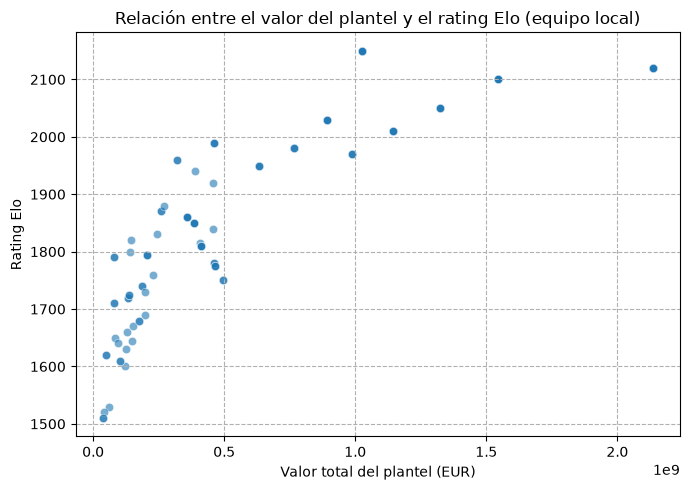

In [26]:
print("Correlación:", df["home_squad_total_value_eur"].corr(df["home_elo"]).round(3))

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='home_squad_total_value_eur', y='home_elo', alpha=0.6)
plt.grid(ls='--')
plt.title('Relación entre el valor del plantel y el rating Elo (equipo local)')
plt.xlabel('Valor total del plantel (EUR)')
plt.ylabel('Rating Elo')
plt.tight_layout()
plt.show()

### 3.2 Numéricas – categórica

Pairplot de cuatro variables numéricas usando como `hue` la variable objetivo `match_result`
(H = gana local, D = empate, A = gana visitante). Permite ver si los resultados se separan
según la fuerza de los equipos.

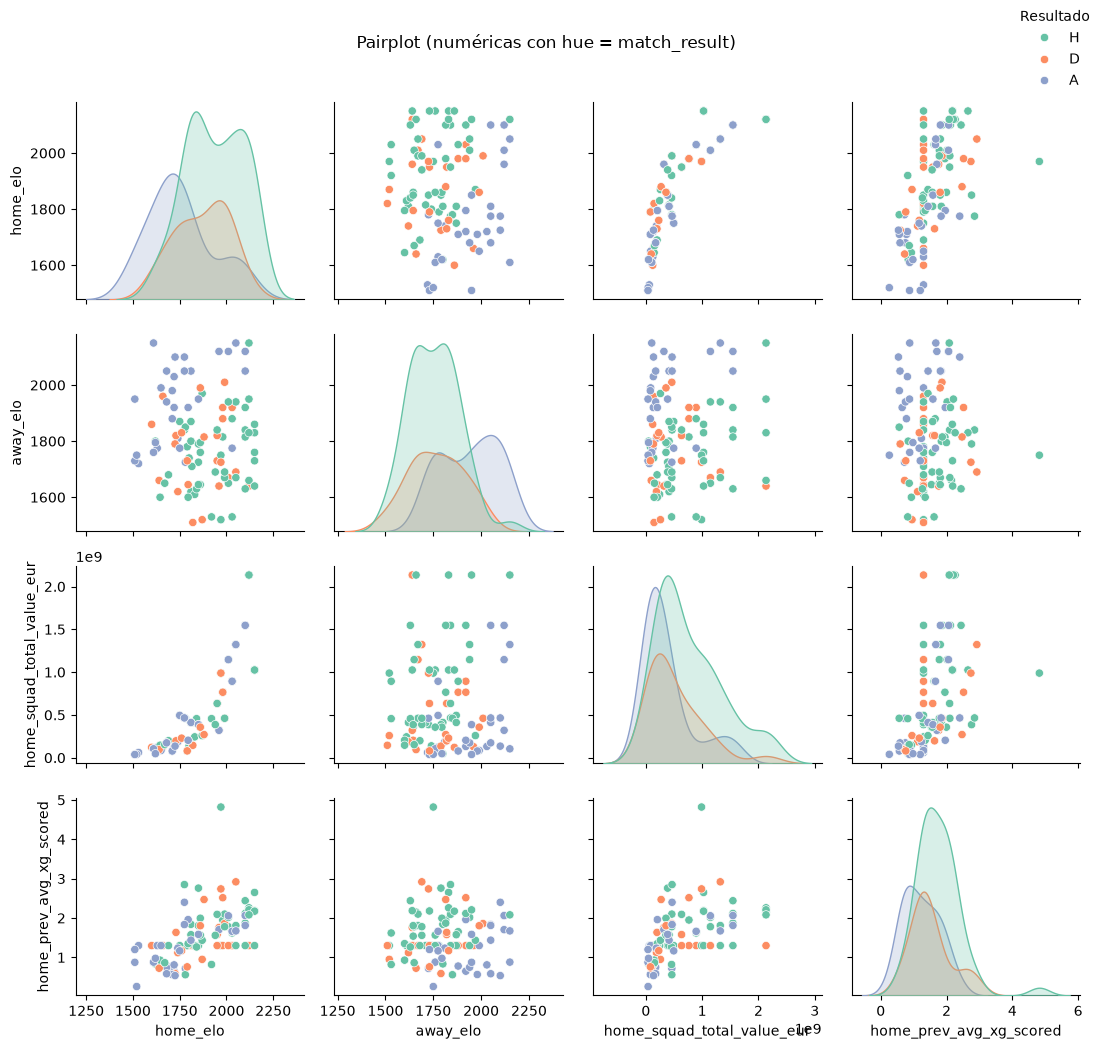

In [27]:
cols = ['home_elo', 'away_elo', 'home_squad_total_value_eur', 'home_prev_avg_xg_scored', 'match_result']

grafico = sns.pairplot(data=df[cols], hue='match_result', palette='Set2')
grafico.figure.suptitle('Pairplot (numéricas con hue = match_result)', y=1.02)

grafico.legend.set_bbox_to_anchor((1, 1))
grafico.legend.set_title('Resultado')

plt.tight_layout()
plt.show()

### 3.3 Categórica – categórica

¿El resultado del partido depende de la confederación a la que pertenece el equipo local?

match_result         A   D   H
home_confederation            
AFC                  4   5   2
CAF                  4   3   6
CONCACAF             7   1   7
CONMEBOL             3   5  10
OFC                  2   0   0
UEFA                10  10  25


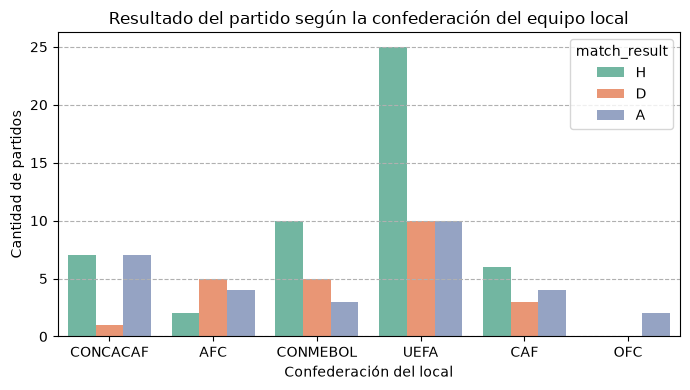

In [28]:
print(pd.crosstab(df['home_confederation'], df['match_result']))

plt.figure(figsize=(7, 4))
sns.countplot(x='home_confederation', hue='match_result', data=df, palette='Set2')
plt.grid(ls='--', axis='y')
plt.title('Resultado del partido según la confederación del equipo local')
plt.xlabel('Confederación del local')
plt.ylabel('Cantidad de partidos')
plt.tight_layout()
plt.show()